# Generate the CSV files with the parameters for the ROBIN simulation

This notebook is intended to synthetically generate the CSV files needed for the ROBIN simulation. The files are generated using the structure of the ROBIN scraping tool. Two output files are obtained:
- `trips.csv`: Contains information about the trips, including the service ID, trip ID, and other relevant details.
- `stops.csv`: Contains information about the stops, including the stop ID, arrival and departure times, and other relevant details.

## 0. Import Libraries

In [1]:
%load_ext autoreload
%autoreload 2

import os

import datetime
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

## 1. Configuration settings

In [2]:
# Parameters and constants for the script
input_xls = '../data/TimetablesMAD-BCN-June2025.xlsx'
output_folder = '../data/MAD-BCN/'
figures_folder = '../figures/MAD-BCN/'
csv_suffix = '_MAD-BCN_2025'

# List of stop IDs for Madrid and Barcelona
STOP_IDS = ['60000', '71801'] # Madrid and Barcelona stations
YEAR = 2025
# Days of the week in Spanish for XLSX sheet names
DAYS_TO_XLSSHEET = ['Lunes','Martes','Miércoles','Jueves','Viernes','Sábado','Domingo']
RENFE_SERVICES = ['AVE', 'AVE INT', 'AVLO']
RENFE_PRICES_INTERVAL = [10, 160]
COMPETITORS_PRICES_INTERVAL = [10, 140]

# Start and end dates
start_date = datetime.date(YEAR, 1, 1)
end_date = datetime.date(YEAR, 1, 1)
end_date = datetime.date(YEAR, 12, 31)

# Set the seed for reproducibility
seed = 2025
np.random.seed(seed)

In [3]:
def get_renfe_price(basic_price, std):
    # Generate a random price for renfe services
    beta_price = 1.2
    beta_std = 0.5
    price = beta_price * basic_price + beta_std * np.random.normal(0, std)

    # Ensure the price is within the specified interval
    price = max(min(price, RENFE_PRICES_INTERVAL[1]), RENFE_PRICES_INTERVAL[0])
    price = round(price, 2)
    return price

def get_competitors_price(ref_price, t, PR1, PR2, t_R1, t_R2, rng=np.random.default_rng(0)):
    """
    Generate the price of a competitor's service using RENFE prices as a reference.

    This function generates a synthetic price for a competitor train service at time `t`, by 
    taking into account the reference/base competitor price (`price`), as well as the
    nearest previous (`PR1`) and next (`PR2`) RENFE prices. It weights these reference prices 
    inversely by the temporal distance (in minutes) to the competitor's departure time, adding 
    a small random perturbation to simulate pricing variability.
    """
    error = rng.normal(0, 10)

    d_tr1 = max(abs((t - t_R1).total_seconds() / 60), 1)
    d_tr2 = max(abs((t - t_R2).total_seconds() / 60), 1)
    denominator = 2/3 + 1/d_tr1 + 1/d_tr2

    price = 2/3 * ref_price/denominator + 1/d_tr1 * PR1/denominator + 1/d_tr2 * PR2/denominator + error
    
    # Ensure the price is within the specified interval
    price = max(min(price, COMPETITORS_PRICES_INTERVAL[1]), COMPETITORS_PRICES_INTERVAL[0])
    price = round(price, 2)

    return price

In [4]:
# Check if the output folder exists, if not create it
if not os.path.exists(output_folder):
    os.makedirs(output_folder)
# Check if stop_times folder exists, if not create it
stop_times_folder = os.path.join(output_folder, 'stop_times')
if not os.path.exists(stop_times_folder):
    os.makedirs(stop_times_folder)
# Check if prices folder exists, if not create it
prices_folder = os.path.join(output_folder, 'prices')
if not os.path.exists(prices_folder):
    os.makedirs(prices_folder)

# Check if the xls file exists
if not os.path.exists(input_xls):
    raise FileNotFoundError(f"The file {input_xls} does not exist.")
# Load the Excel file
xls = pd.ExcelFile(input_xls)
# Get the names of all sheets in the Excel file
sheet_names = xls.sheet_names

# Create an empty dataframe to store the stop_times
stop_times = pd.DataFrame(columns=['service_id','stop_id','arrival','departure'])
# Create an empty dataframe to store the prices_ext
prices_ext = pd.DataFrame(columns=['trip_id','origin','destination','tsp','train_type','departure','arrival','duration','service_id','capacity','train_model','original_price_scraping','BasicSeat'])

# Create a dictionary to map the travel time and train_type to the trip_id
time_to_trip_id = {}
next_trip_id = 1

## 2. Generate the stopTimes and prices CSV

In [5]:
# Generate all dates of the year
current_date = start_date
while current_date <= end_date:
    day_of_week = current_date.weekday()
    current_sheet = DAYS_TO_XLSSHEET[day_of_week]
    
    print(f"{current_date.strftime('%d-%m-%Y')} : {current_sheet}")


    # Generate the services for the current date
    df = pd.read_excel(xls, sheet_name=current_sheet)

    # Remove rows with all NaN values
    df = df.dropna(how='all')

    # Check if the dataframe is empty
    if df.empty:
        raise ValueError(f"The sheet {current_sheet} is empty.")

    # Preprocess the dataframe
    for index, _ in df.iterrows():
        # Check if Hora Salida and Hora Llegada is a str or datetime and convert it to datetime HH:MM
        if isinstance(df.at[index, 'Hora Salida'], str):
            df.at[index, 'Hora Salida'] = datetime.datetime.strptime(df.at[index, 'Hora Salida'], '%H:%M').time()
        elif isinstance(df.at[index, 'Hora Salida'], datetime.time):
            pass
        else:
            raise ValueError(f"Invalid format for Hora Salida: {df.at[index, 'Hora Salida']}")
        if isinstance(df.at[index, 'Hora Llegada'], str):
            df.at[index, 'Hora Llegada'] = datetime.datetime.strptime(df.at[index, 'Hora Llegada'], '%H:%M').time()
        elif isinstance(df.at[index, 'Hora Llegada'], datetime.time):
            pass
        else:
            raise ValueError(f"Invalid format for Hora Llegada: {df.at[index, 'Hora Llegada']}")
        
    # Order the dataframe by departure time
    df = df.sort_values(by='Hora Salida')

    # Compute the std of renfe prices_ext for the current date
    renfe_price_std = {}
    for renfe_service in RENFE_SERVICES:
        service_data = df[df['Nombre del Servicio'] == renfe_service]
        if not service_data.empty:
            renfe_price_std[renfe_service] = service_data['Precio'].std()
            if np.isnan(renfe_price_std[renfe_service]):
                renfe_price_std[renfe_service] = 0
        else:
            renfe_price_std[renfe_service] = 0

    # Generate an individual service
    for index, row in df.iterrows():
        train_type = row['Nombre del Servicio']

        departure = datetime.datetime.combine(current_date, row['Hora Salida'])
        arrival = datetime.datetime.combine(current_date, row['Hora Llegada'])
        duration = arrival - departure
        departure_int = 0
        arrival_int = int(duration.total_seconds() / 60)

        # Check if the arrival_int and train_type combination already exists
        if f"{arrival_int}_{train_type}" not in time_to_trip_id:
            # trip_id is a 5 digit number
            trip_id = str(next_trip_id).zfill(5)
            time_to_trip_id[f"{arrival_int}_{train_type}"] = trip_id
            next_trip_id += 1
        else:
            trip_id = time_to_trip_id[f"{arrival_int}_{train_type}"]

        service_id = f"{trip_id}_{current_date.strftime('%d-%m-%Y')}-{row['Hora Salida'].strftime('%H.%M')}"
        
        # Append the new service to the stop_times dataframe
        new__stop_rows = pd.DataFrame([
            {
                'service_id': service_id,
                'stop_id': STOP_IDS[0],
                'arrival': departure_int,
                'departure': departure_int
            },
            {
                'service_id': service_id,
                'stop_id': STOP_IDS[1],
                'arrival': arrival_int,
                'departure': arrival_int
            }
        ])
        stop_times = pd.concat([stop_times, new__stop_rows], ignore_index=True)

        # Store information about the train capacity and model
        train_capacity = row['Capacidad']
        train_model = row['Modelo de Tren']

        # Keep original Excel price before any synthetic modifications
        original_price_scraping = row['Precio']

        price_basic = np.nan
        # Generate the prices_ext for the current service if the service is from RENFE_SERVICES
        if row['Nombre del Servicio'] in RENFE_SERVICES:
            # Generate a random price for the current service
            price_basic = get_renfe_price(row['Precio'], renfe_price_std[row['Nombre del Servicio']])
        else:
            price_basic = row['Precio']

        # Fill the prices_ext dataframe with the prices_ext for the current service
        new_price_row = pd.DataFrame([
            {
                'trip_id': trip_id,
                'origin': STOP_IDS[0],
                'destination': STOP_IDS[1],
                'tsp': train_type,
                'train_type': train_type,
                'departure': departure,
                'arrival': arrival,
                'duration': duration,
                'service_id': service_id,
                'capacity': train_capacity,
                'train_model': train_model,
                'original_price_scraping': original_price_scraping,
                'BasicSeat': price_basic
            }
        ])
        prices_ext = pd.concat([prices_ext, new_price_row], ignore_index=True)
        

    current_date += datetime.timedelta(days=1)


# Fill the price columns of the competitor services using RENFE prices_ext as reference
for index, row in prices_ext.iterrows():
    if row['train_type'] not in RENFE_SERVICES:
        # Get the reference price of the service
        ref_price = row['BasicSeat']

        # Get the previous RENFE price
        previous_renfe_prices_ext = prices_ext[(prices_ext['departure'] < row['departure']) & (prices_ext['train_type'].isin(RENFE_SERVICES))]
        if previous_renfe_prices_ext.empty:
            # Mean RENFE price of that day
            PR1 = prices_ext[prices_ext['departure'].dt.date == row['departure'].date() 
                                         & (prices_ext['train_type'].isin(RENFE_SERVICES))]['BasicSeat'].mean()
        else:
            PR1 = previous_renfe_prices_ext.iloc[-1]['BasicSeat']
        # Get the next RENFE price
        next_renfe_prices_ext = prices_ext[(prices_ext['departure'] > row['departure']) & (prices_ext['train_type'].isin(RENFE_SERVICES))]
        if next_renfe_prices_ext.empty:
            # Mean RENFE price of that day
            PR2 = prices_ext[prices_ext['departure'].dt.date == row['departure'].date() 
                                         & (prices_ext['train_type'].isin(RENFE_SERVICES))]['BasicSeat'].mean()
        else:
            PR2 = next_renfe_prices_ext.iloc[0]['BasicSeat']

        # Get the travel time of the renfe services
        t = row['departure']
        t_R1 = previous_renfe_prices_ext.iloc[-1]['departure']
        t_R2 = next_renfe_prices_ext.iloc[0]['departure']

        # Generate the price
        price = get_competitors_price(ref_price, t, PR1, PR2, t_R1, t_R2, rng=np.random.default_rng(seed=seed))
        prices_ext.at[index, 'BasicSeat'] = price

# Prices datset is prices_ext witout the capacity, train_model and original_price_scraping columns
prices = prices_ext.drop(columns=['capacity', 'train_model'])


01-01-2025 : Miércoles
02-01-2025 : Jueves
03-01-2025 : Viernes
04-01-2025 : Sábado
05-01-2025 : Domingo
06-01-2025 : Lunes
07-01-2025 : Martes
08-01-2025 : Miércoles


/var/folders/n5/s8_w_cgn3jd6kv8h7psy1jnr0000gn/T/ipykernel_53216/1857677319.py:121: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  prices_ext = pd.concat([prices_ext, new_price_row], ignore_index=True)


09-01-2025 : Jueves
10-01-2025 : Viernes
11-01-2025 : Sábado
12-01-2025 : Domingo
13-01-2025 : Lunes
14-01-2025 : Martes
15-01-2025 : Miércoles
16-01-2025 : Jueves
17-01-2025 : Viernes
18-01-2025 : Sábado
19-01-2025 : Domingo
20-01-2025 : Lunes
21-01-2025 : Martes
22-01-2025 : Miércoles
23-01-2025 : Jueves
24-01-2025 : Viernes
25-01-2025 : Sábado
26-01-2025 : Domingo
27-01-2025 : Lunes
28-01-2025 : Martes
29-01-2025 : Miércoles
30-01-2025 : Jueves
31-01-2025 : Viernes
01-02-2025 : Sábado
02-02-2025 : Domingo
03-02-2025 : Lunes
04-02-2025 : Martes
05-02-2025 : Miércoles
06-02-2025 : Jueves
07-02-2025 : Viernes
08-02-2025 : Sábado
09-02-2025 : Domingo
10-02-2025 : Lunes
11-02-2025 : Martes
12-02-2025 : Miércoles
13-02-2025 : Jueves
14-02-2025 : Viernes
15-02-2025 : Sábado
16-02-2025 : Domingo
17-02-2025 : Lunes
18-02-2025 : Martes
19-02-2025 : Miércoles
20-02-2025 : Jueves
21-02-2025 : Viernes
22-02-2025 : Sábado
23-02-2025 : Domingo
24-02-2025 : Lunes
25-02-2025 : Martes
26-02-2025 : Mi

In [6]:
stop_times

,service_id,stop_id,arrival,departure
0,00001_01-01-2025-06.12,60000,0,0
1,00001_01-01-2025-06.12,71801,157,157
2,00002_01-01-2025-06.22,60000,0,0
3,00002_01-01-2025-06.22,71801,157,157
4,00003_01-01-2025-06.27,60000,0,0
...,...,...,...,...
30871,00020_31-12-2025-20.27,71801,201,201
30872,00005_31-12-2025-21.02,60000,0,0
30873,00005_31-12-2025-21.02,71801,172,172
30874,00007_31-12-2025-21.07,60000,0,0


In [7]:
prices_ext

,trip_id,origin,destination,tsp,train_type,departure,arrival,duration,service_id,capacity,train_model,original_price_scraping,BasicSeat
0,00001,60000,71801,AVLO,AVLO,2025-01-01 06:12:00,2025-01-01 08:49:00,0 days 02:37:00,00001_01-01-2025-06.12,581.0,S-106,29.00,34.52
1,00002,60000,71801,IRYO,IRYO,2025-01-01 06:22:00,2025-01-01 08:59:00,0 days 02:37:00,00002_01-01-2025-06.22,461.0,S-109,27.58,11.90
2,00003,60000,71801,AVE,AVE,2025-01-01 06:27:00,2025-01-01 09:25:00,0 days 02:58:00,00003_01-01-2025-06.27,359.0,S-103,40.20,55.70
3,00004,60000,71801,AVE,AVE,2025-01-01 06:57:00,2025-01-01 09:34:00,0 days 02:37:00,00004_01-01-2025-06.57,414.0,S-103,81.35,82.99
4,00005,60000,71801,OUIGO,OUIGO,2025-01-01 07:02:00,2025-01-01 09:54:00,0 days 02:52:00,00005_01-01-2025-07.02,509.0,S-108,33.00,21.58
...,...,...,...,...,...,...,...,...,...,...,...,...,...
15433,00004,60000,71801,AVE,AVE,2025-12-31 20:05:00,2025-12-31 22:42:00,0 days 02:37:00,00004_31-12-2025-20.05,414.0,S-103,40.70,21.42
15434,00009,60000,71801,IRYO,IRYO,2025-12-31 20:22:00,2025-12-31 23:14:00,0 days 02:52:00,00009_31-12-2025-20.22,461.0,S-109,29.26,12.24
15435,00020,60000,71801,AVE,AVE,2025-12-31 20:27:00,2025-12-31 23:48:00,0 days 03:21:00,00020_31-12-2025-20.27,414.0,S-103,34.45,55.58
15436,00005,60000,71801,OUIGO,OUIGO,2025-12-31 21:02:00,2025-12-31 23:54:00,0 days 02:52:00,00005_31-12-2025-21.02,509.0,S-108,33.00,18.19


## 3. Plot the generated data

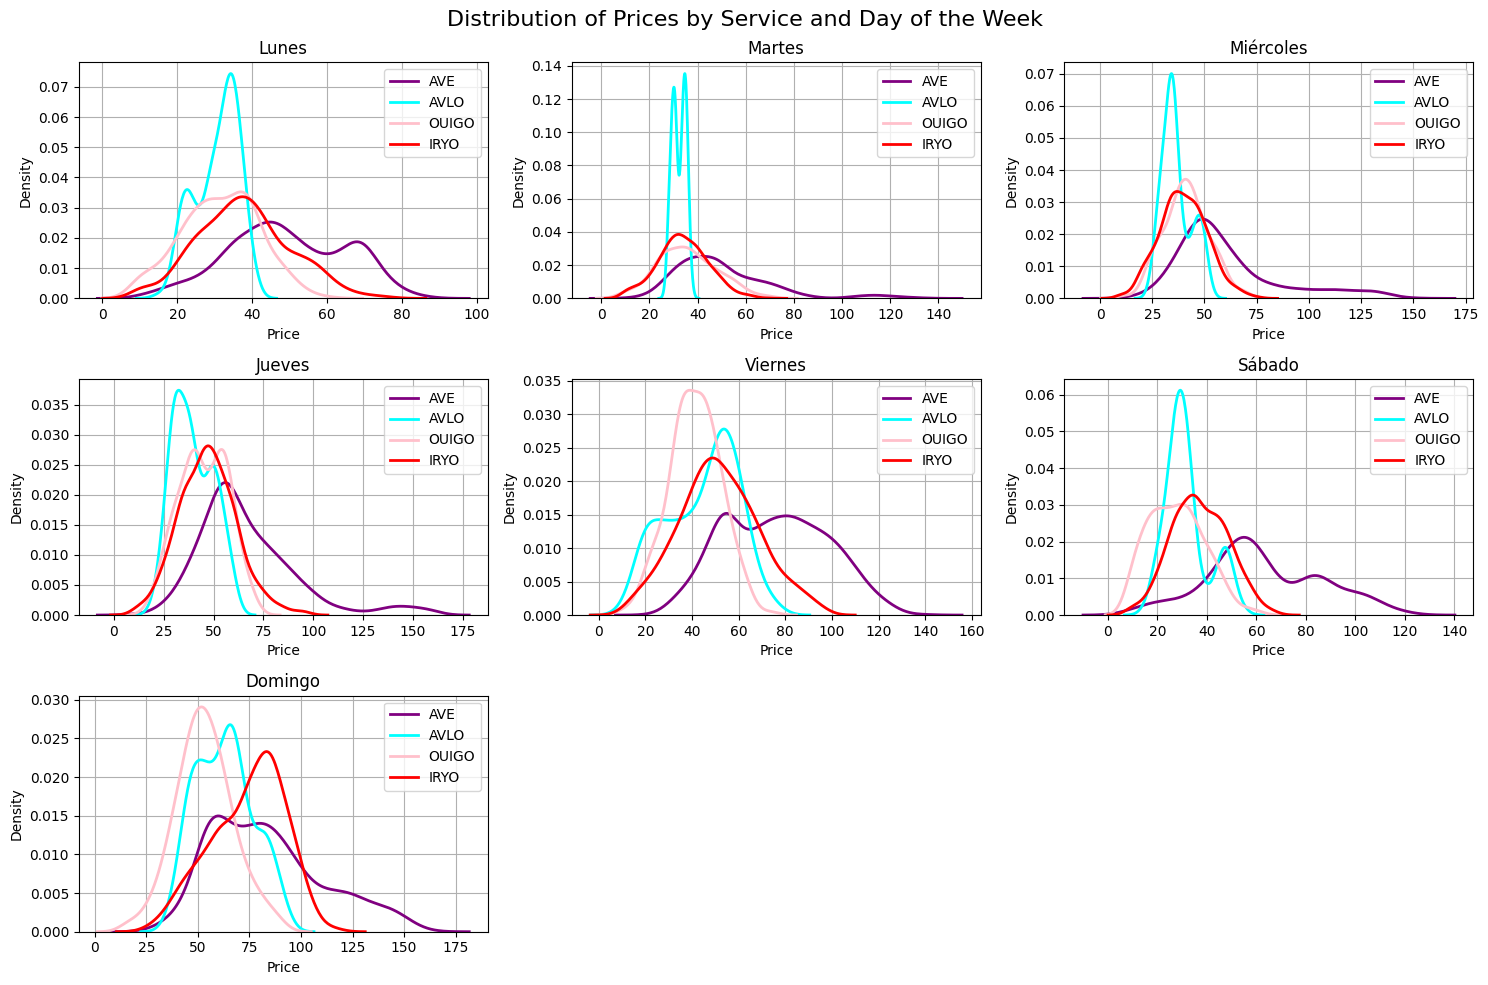

In [8]:
# Plot the distribution of prices for each service and day of the week
fig, axs = plt.subplots(3, 3, figsize=(15, 10))
for day in range(7):
    ax = axs[day // 3, day % 3]
    for service in ['AVE', 'AVLO', 'OUIGO', 'IRYO']:
        if service == 'AVE':
            prices_day = prices[(prices['departure'].dt.weekday == day) & (prices['train_type'].isin(['AVE', 'AVE INT']))]
            color = 'purple'
        elif service == 'AVLO':
            prices_day = prices[(prices['departure'].dt.weekday == day) & (prices['train_type'] == 'AVLO')]
            color = 'aqua'
        elif service == 'OUIGO':
            prices_day = prices[(prices['departure'].dt.weekday == day) & (prices['train_type'] == 'OUIGO')]
            color = 'pink'
        elif service == 'IRYO':
            prices_day = prices[(prices['departure'].dt.weekday == day) & (prices['train_type'] == 'IRYO')]
            color = 'red'
        sns.kdeplot(prices_day['BasicSeat'], label=service, color=color, lw=2, ax=ax)
    ax.set_title(f'{DAYS_TO_XLSSHEET[day]}')
    ax.set_xlabel('Price')
    ax.set_ylabel('Density')
    ax.legend()
    ax.grid()
for day in range(7, 9):
    # Hide the last two subplots
    fig.delaxes(axs[day // 3, day % 3])
plt.suptitle('Distribution of Prices by Service and Day of the Week', fontsize=16)
plt.tight_layout()
# Save the figure and show it
if not os.path.exists(figures_folder):
    os.makedirs(figures_folder)
plt.savefig(os.path.join(figures_folder, 'prices_distribution_by_service_and_day.pdf'), dpi=300)
plt.show()


## 4. Save the generated data to CSV files

In [9]:
# Save the stop_times dataframe to a CSV file
stop_times_file = os.path.join(stop_times_folder, f"stop_times{csv_suffix}.csv")
stop_times.to_csv(stop_times_file, index=False)
print(f"stop_times saved to {stop_times_file}")

# Save the prices dataframe to a CSV file
prices_file = os.path.join(prices_folder, f"prices{csv_suffix}.csv")
prices.to_csv(prices_file, index=False)
print(f"prices saved to {prices_file}")

# Save the prices_ext dataframe to a CSV file
prices_ext_file = os.path.join(prices_folder, f"prices_ext{csv_suffix}.csv")
prices_ext.to_csv(prices_ext_file, index=False)
print(f"prices_ext saved to {prices_ext_file}")


stop_times saved to ../data/MAD-BCN/stop_times/stop_times_MAD-BCN_2025.csv
prices saved to ../data/MAD-BCN/prices/prices_MAD-BCN_2025.csv
prices_ext saved to ../data/MAD-BCN/prices/prices_ext_MAD-BCN_2025.csv
